# Item Recommendation Using Graph Neuronal Networks

In this notebook we build a recommendation system for items in a League of Legends match using Graph Neuronal Networks. 
We took the matches from the [Ranked Games 2020](https://www.kaggle.com/datasets/gyejr95/league-of-legendslol-ranked-games-2020-ver1) datasets containing matches from the best players in Korea (So we assume they know what they are doing).   

We encode a match into nodes (Arbitrary Players, Champions, Items, SummonerSpells, Roles & Positions) and edges and feed it in a Graph Convolutional Network. 
For a target player, we add edges form this player to all possible item nodes and train the model (binary classifier) if the edge was present in the actual data or not. 

By yielding the most likely edges, we can recommend a buying oder to the target player. 

## Approach

First, we create nodes for all possible Champions, Roles, Lanes, Items, SummonerSpells and 10 Players of a match. 
Then we encode every match as edges from one of the 10 players to the other nodes, creating a bipartite network.  
Furthermore, we add an edge from the first player to all items, so the model can learn which of them to recommend.

Afterwards, we create the target vector (size of all edges) containing a 1 if the edge is present in the data or 0 if it's not. 

The nodes and edges are then fed into a Graph Convolutional Network that first performs 3 graph convolutions.
The output it then fed into a linear network that returns a vector as big as the number of edges. 

The input data is described in more detail in the following illustration. 

![GCN](../assets/GCN.png)

#### Imports and Seeds

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from colorama import Back, Style
from sklearn.model_selection import train_test_split

from util.db.graph import Neo4JConnector

In [2]:
neo4j = Neo4JConnector.create_from_config("../config.ini")

random_state = 4201312
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Creating the Input-Nodes 

Here we extract all possible nodes from the Neo4J Database which are then used as input for the GCN. 
We extract the Champions, Roles, Lanes, Items, SummonerSpells and add reserve 10 nodes for the arbitrary players.

Every node is then assigned with a unique position in the nodes input node matrix.
The input node matrix contains the one-hot-encoded types. 
So every row has all zeros except one 1 indicating the nodes type.  


In [3]:
#{Player_1, ..., Player_10, Item_Youmuu's Wake, Item_Tracker's Knife, ..., Champion_Fiora, ...}
node_names = set({f"Player_{i}" for i in range(10)}) 
target_types = ["Champion", "Role", "Lane", "Item", "SummonerSpell"] 
node_types = ["Player"] 

for nt in target_types:
    node_types.append(nt)
    for r in neo4j.exec(f"MATCH (x:{nt}) RETURN x")[0]:
        node_names.add(f"{next(iter(r['x'].labels))}_{r['x']['name']}") 

node_encodings = {x: i for i, x in enumerate(node_names)}
node_encodings_rev = {node_encodings[x]: x for x in node_encodings}
node_types_encoding = {x:i for i,x in enumerate(node_types)}
items = [x for x in node_encodings if x.startswith("Item")]

In [4]:
# Creating the node matrix where the node type is one-hot-encoded. So every row has all zeros except one 1 indicating the nodes type
nodes_matrix = torch.zeros((len(node_encodings), len(node_types))).type(torch.float32)
    
for node_name in node_encodings:
    nodes_matrix[node_encodings[node_name], node_types_encoding[node_name.split("_")[0]]] = 1

The last step is calculate the maximum size of the output vector, defined es the maximum amount of possible edges

Max. Number of Edges = 10 (players) where every one has 2 summoner spells, 1 Role, 1 Lane, 1 Champ and 7 Items.
The target player nodes are "hidden" in the items so the model don't learn that all true edges are at the start of the vector.  

In [5]:
max_number_edges = ((2+1+1+1+7) * 10) - 7 + len(items)
max_number_edges

673

### Encoding the matches 

Here, we extract all suitable matches and encode them as input for the model. 

We use the CLASSIC game mode, since all game modes include other items, 
and we want to train the model only on the standard game. 

Also in the early state of the game the items look differently, so we filter games that are at leased half an hour long. 

In [6]:
def get_matches(limit = None):
    matches_query = """MATCH (m:Match) 
        WHERE m.gameType = "MATCHED_GAME" AND m.gameMode = "CLASSIC" AND 
            apoc.date.parse(toString(m.gameDuration), 's', 'HH:mm:ssX') > 1800
        RETURN m"""
    
    if limit is not None:
        matches_query = matches_query + " LIMIT " + str(limit)
        
    return np.array([x["m"]["matchID"] for x in neo4j.exec(matches_query)[0]])

matches = get_matches(1000)

Here we encode the match (edges list) and target vector as described at the start. 

In [7]:
def encode_match(match_id):
    result = neo4j.exec(f"""
        MATCH (m: Match {{matchID: $matchid}})-[co:CONSISTS_OF]->(q:Queue)<-[pi:PLAYS_IN]-(p:PlayerInMatch)-[x]->(y: ({'|'.join(target_types)})) 
        RETURN q, p, x, y""", matchid=match_id)
    
    player_encodings = {}
    edge_list = [[], []]
    result_vector = []
    target_items = []
    
    target_player = node_encodings[f"Player_0"]
    
    for x in result[0]:
        player_id = x["p"].element_id
        node_name = f"{next(iter(x['y'].labels))}_{x['y']['name']}" 
        
        if player_id not in player_encodings:
            player_encodings[player_id] = f"Player_{len(player_encodings)}"
        
        player_encoding = node_encodings[player_encodings[player_id]]
        object_encoding = node_encodings[node_name]
        
        if player_encoding == target_player and node_name.startswith("Item_"):
            target_items.append(object_encoding)
        else: 
            edge_list[0].append(player_encoding)
            edge_list[1].append(object_encoding)
            result_vector.append(1)
    
    for item in items:
        item_encoding = node_encodings[item]
        edge_list[0].append(target_player)
        edge_list[1].append(item_encoding)
        result_vector.append(1 if item_encoding in target_items else 0)
    
    while len(result_vector) < max_number_edges:
        edge_list[0].append(-1)
        edge_list[1].append(-1)
        result_vector.append(0)
        
    return torch.tensor(edge_list), torch.tensor(result_vector).type(torch.float64)

encoded_matches = [encode_match(match) for match in tqdm.tqdm(matches)]

100%|██████████| 1000/1000 [00:25<00:00, 39.54it/s]


Here we check if the encoding worked correctly. 
All "known" edges are at the start (edges from all players except the target players items).
Afterwards, we include edges from the target player to all possible items in the same order. 

The target vector includes the information if the edge is an actual edge (TRUE POSITIVE) or not (FALSE POSITIVE).  

In [8]:
for player, player_object, is_true in zip(encoded_matches[0][0][0], encoded_matches[0][0][1], encoded_matches[0][1]):
    if player.item() == -1: 
        print(Back.YELLOW + "   PADDING    " + Style.RESET_ALL)
        continue
        
    indicator = Back.GREEN + "TRUE POSITIVE " + Style.RESET_ALL if is_true.item() == 1 else Back.RED + "FALSE POSITIVE" + Style.RESET_ALL
    print(indicator, node_encodings_rev[player.item()], node_encodings_rev[player_object.item()])

TRUE POSITIVE  Player_0 Lane_MIDDLE
TRUE POSITIVE  Player_0 SummonerSpell_Flash
TRUE POSITIVE  Player_0 Role_SOLO
TRUE POSITIVE  Player_0 SummonerSpell_Teleport
TRUE POSITIVE  Player_0 Champion_Kassadin
TRUE POSITIVE  Player_1 Item_Mobility Boots
TRUE POSITIVE  Player_1 Champion_Karma
TRUE POSITIVE  Player_1 Item_Oracle Lens
TRUE POSITIVE  Player_1 Lane_BOTTOM
TRUE POSITIVE  Player_1 Item_Faerie Charm
TRUE POSITIVE  Player_1 SummonerSpell_Flash
TRUE POSITIVE  Player_1 Item_Redemption
TRUE POSITIVE  Player_1 Item_NO ITEM
TRUE POSITIVE  Player_1 SummonerSpell_Ignite
TRUE POSITIVE  Player_1 Item_Athene's Unholy Grail
TRUE POSITIVE  Player_1 Item_Shard of True Ice
TRUE POSITIVE  Player_1 Role_DUO_SUPPORT
TRUE POSITIVE  Player_2 Item_Farsight Alteration
TRUE POSITIVE  Player_2 Item_Infinity Edge
TRUE POSITIVE  Player_2 Champion_Miss Fortune
TRUE POSITIVE  Player_2 Item_Berserker's Greaves
TRUE POSITIVE  Player_2 Role_DUO_CARRY
TRUE POSITIVE  Player_2 SummonerSpell_Flash
TRUE POSITIVE  Playe

Now we create a train (80%), test (10%) and validation (10%) split. 

We didn't use batches since the model had issues with that.   

In [9]:
train_data, test_validation_data = train_test_split(encoded_matches, test_size=0.2, random_state=random_state)
test_data, validation_data = train_test_split(test_validation_data, test_size=0.5, random_state=random_state)

"Train: ", len(train_data), "Test: ", len(test_data), "Validation: ", len(validation_data)

('Train: ', 800, 'Test: ', 100, 'Validation: ', 100)

## Training

Here we define the model and start the training. 

The model consists of 3 Graph Convolutions and one linear layer. 

In [10]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class EdgeClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(EdgeClassifier, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels * 2, out_channels)
    
    def forward(self, x, edge_index):
        # Node feature transformation
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)   
        x = self.conv3(x, edge_index)
        
        # Create edge features by concatenating node features of connected nodes
        edge_features = torch.cat([x[edge_index[0]], x[edge_index[1]]], dim=1)
        
        # Classify the edge
        edge_predictions = self.fc(edge_features).view(-1)
        
        return edge_predictions

def create_model():
    return EdgeClassifier(nodes_matrix.shape[1], 100, 1)

In [11]:
create_model()

EdgeClassifier(
  (conv1): GCNConv(6, 100)
  (conv2): GCNConv(100, 100)
  (conv3): GCNConv(100, 100)
  (fc): Linear(in_features=200, out_features=1, bias=True)
)

Now we train the model using a maximum of 100 epochs with early stopping (tracking the best performing model). 
As optimizer, we chose an Adam optimizer with a learning rate of 0.001. The Loss function is defined as a Binary Cross Entropy.   

For validation, we then print the training and validation losses for every epoch.

In [12]:
model = create_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()

if torch.cuda.is_available():
    mode = model.cuda()
    nodes_matrix = nodes_matrix.cuda()
    
def train():
    model.train()
    
    loss_sum = 0
    for (edge_list, result_vector) in train_data:
        optimizer.zero_grad()
        
        if torch.cuda.is_available():
            edge_list, result_vector = edge_list.cuda(), result_vector.cuda()
        
        out = model(nodes_matrix, edge_list)
        loss = criterion(out, result_vector)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
        
    return loss_sum / len(train_data)

def evaluate():
    losses = 0
        
    model.eval()
    with torch.no_grad():
        for (edge_list, result_vector) in validation_data:
            if torch.cuda.is_available():
                edge_list, result_vector = edge_list.cuda(), result_vector.cuda()
            
            out = model(nodes_matrix, edge_list)
            losses += criterion(out, result_vector).item()
            
        return losses / len(validation_data)

def train_model(num_epoch=100, early_stopping=None):
    test_losses, validation_losses = [], []
    lowest_loss = float('inf') 
    early_stopping_count = 0
    best_model = None
    
    for epoch in range(num_epoch):
        loss_train = train()
        test_losses.append(loss_train)
        
        loss_validation  = evaluate()
        validation_losses.append(loss_validation)
        
        if early_stopping is not None:
            if lowest_loss > loss_validation:
                lowest_loss = loss_validation
                early_stopping_count = 0
                best_model = f"models/model_seal_{epoch}.pt"
                torch.save(model.state_dict(), best_model)
            else:
                early_stopping_count += 1
        
            if early_stopping_count == early_stopping:
                print(f'Early stopping at epoch {epoch}')
                break
        
        print(f'Epoch {epoch+1}, Loss Train: {loss_train}, Loss Validation: {loss_validation}')
    
    return best_model, test_losses, validation_losses

train_info = train_model(early_stopping=5)

Epoch 1, Loss Train: 0.16889127195885553, Loss Validation: 0.12992021504250909
Epoch 2, Loss Train: 0.12920616504497942, Loss Validation: 0.1292268645460149
Epoch 3, Loss Train: 0.1285802038412691, Loss Validation: 0.1281363770942425
Epoch 4, Loss Train: 0.12803155689879497, Loss Validation: 0.12729836058338104
Epoch 5, Loss Train: 0.12751790639845056, Loss Validation: 0.12670933671333048
Epoch 6, Loss Train: 0.1271601353812839, Loss Validation: 0.1263783490544746
Epoch 7, Loss Train: 0.12690946515356674, Loss Validation: 0.1262686712390609
Epoch 8, Loss Train: 0.12675953628311804, Loss Validation: 0.12616500029215583
Epoch 9, Loss Train: 0.12670336957193912, Loss Validation: 0.1260600627970677
Epoch 10, Loss Train: 0.12664233947446907, Loss Validation: 0.12606424887765127
Epoch 11, Loss Train: 0.12659575276725815, Loss Validation: 0.12609486358971575
Epoch 12, Loss Train: 0.12661101094967508, Loss Validation: 0.12607701105235086
Epoch 13, Loss Train: 0.1265699584729033, Loss Validatio

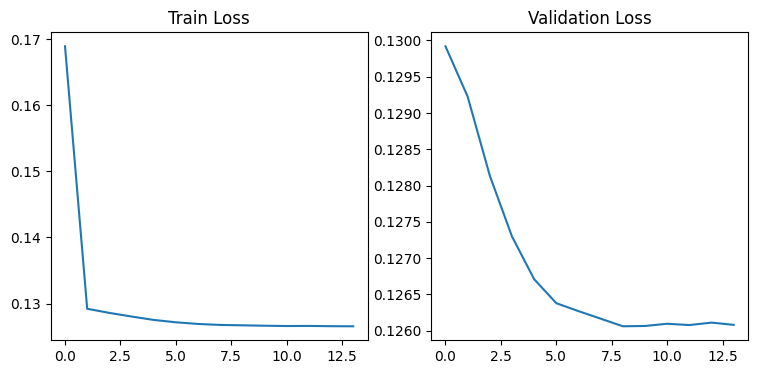

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.plot(train_info[1])
ax2.plot(train_info[2])
ax1.title.set_text('Train Loss')
ax2.title.set_text('Validation Loss')
plt.savefig("../img/train_loss_item_prediction_negative_sampling.png")
plt.show()

## Evaluation

To evaluate the model, we predict an output vector for every match and calculate:  
* True Positives: Edges that are present in the data (items that the target player bought) and classified as such
* False Positives: Edges which are classified as present in the data but are not
* True Negatives: Edges which are artificially infused in the data and classified as false edges
* False Negatives: Edges that are in the data but are not classified as such by the model (Most interesting class for error analysis)
* Quantitative Evaluation Metrics: Precision, Recall & F1 

For error analysis we also collect:
* Items which the player actually bought
* The Recommendation (in order) by the model

In [14]:
model = create_model()
model.load_state_dict(torch.load(train_info[0]))
if torch.cuda.is_available():
    model = model.cuda()

In [15]:
def get_match_evaluation(edge_list: torch.tensor, result_vector: torch.tensor, response: torch.tensor):
    prediction = (torch.sigmoid(response) > 0.5).float()
    
    tp, tn, fp, fn = [], [], [], []
    recommendation = []
    actual_data = []
    
    for i in range(len(edge_list[0])):
        edge_x, edge_y = edge_list[0][i].item(), edge_list[1][i].item()
        edge_x = "PADDING" if edge_x == -1 else node_encodings_rev[edge_x]
        edge_y = "PADDING" if edge_y == -1 else node_encodings_rev[edge_y]
        is_predicted = prediction[i].item() == 1
        is_actual = result_vector[i].item() == 1
        if is_predicted and is_actual:
            tp.append((edge_x, edge_y))
        elif not is_predicted and not is_actual:
            tn.append((edge_x, edge_y))
        elif not is_predicted and is_actual:
            fn.append((edge_x, edge_y))
        else:
            fp.append((edge_x, edge_y))
            
        if is_predicted:
            recommendation.append(((edge_x, edge_y), response[i].item()))
        if is_actual:
            actual_data.append((edge_x, edge_y))
    
    player_recommendation = filter(lambda x: x[0][0] == "Player_0" and x[0][1].startswith("Item_"), recommendation)
    player_item_recommendation = sorted(player_recommendation, key=lambda x: x[1], reverse=True)

    player_items = list(filter(lambda x: x[0] == "Player_0" and x[1].startswith("Item_"), actual_data))
    
    cm = [[float(len(tp)), float(len(fp))], [float(len(fn)), float(len(tn))]]
    precision = cm[0][0] / (cm[0][0] + cm[0][1])
    recall = cm[0][0] / (cm[0][0] + cm[1][0])
    
    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn, "cm": cm,
        "precision": precision, "recall": recall, 
        "f1": 2 * precision * recall / (precision + recall),
        "accuracy": (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1]),
        "player_items": player_items,
        "recommendation": player_item_recommendation
    }


def evaluate_test():
    model.eval()
    
    match_evaluations = []
    with torch.no_grad():
        for edge_list, result_vector in test_data:
            if torch.cuda.is_available():
                edge_list, result_vector = edge_list.cuda(), result_vector.cuda()
        
            edge_list, result_vector = edge_list, result_vector.type(torch.float64)
            
            out = model(nodes_matrix, edge_list)
            match_evaluation = get_match_evaluation(edge_list.cpu(), result_vector.cpu(), out.cpu())
            match_evaluations.append(match_evaluation)
            
    return match_evaluations    

test_evaluation = evaluate_test()

In [16]:
precision = list(map(lambda x: x["precision"],test_evaluation))
recall = list(map(lambda x: x["recall"],test_evaluation))
f1 = list(map(lambda x: x["f1"],test_evaluation))
false_negatives = list(map(lambda x: x["cm"][1][0],test_evaluation))
false_positives = list(map(lambda x: x["cm"][0][1],test_evaluation))

print("Average Precision: \t\t\t\t", np.mean(precision))
print("Average Recall: \t\t\t\t", np.mean(recall))
print("Average F1 Score: \t\t\t\t", np.mean(f1)) 
print("Average # False Positive: \t", np.mean(false_positives) )
print("Average # False Negative: \t", np.mean(false_negatives) )

Average Precision: 				 0.749653034207158
Average Recall: 				 0.9741951087261458
Average F1 Score: 				 0.8472268398822235
Average # False Positive: 	 38.89
Average # False Negative: 	 3.08


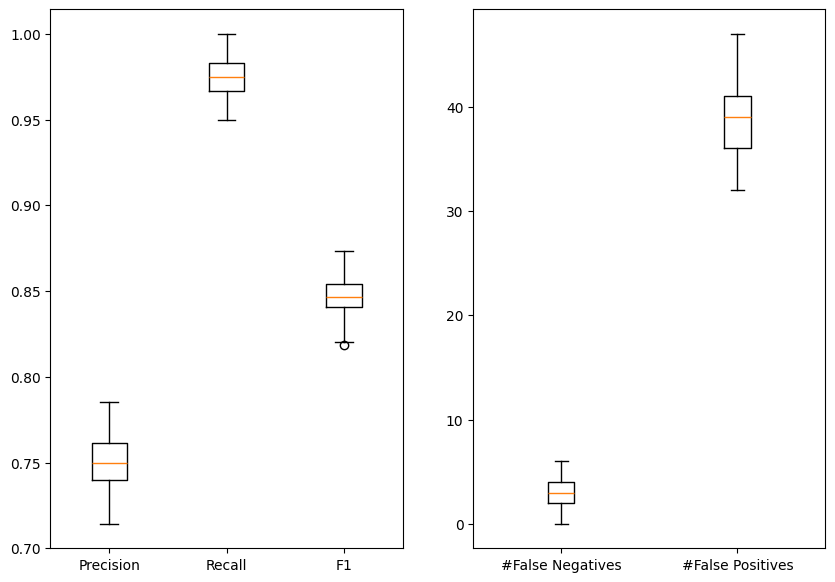

In [17]:
fix, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 7))
ax1.boxplot([precision, recall, f1])
ax1.set_xticklabels(['Precision', 'Recall', "F1"])

ax2.boxplot([false_negatives, false_positives])
ax2.set_xticklabels(["#False Negatives", "#False Positives"])


plt.savefig("../img/evaluation_gcnconv.png")
plt.show()

In [19]:
idx = 1
player_edges = list(filter(lambda x: x[0] == "Player_0", test_evaluation[idx]["tp"]))
player_edges, test_evaluation[idx]["player_items"], test_evaluation[idx]["recommendation"]

([('Player_0', "Champion_Kai'Sa"),
  ('Player_0', 'Lane_BOTTOM'),
  ('Player_0', 'SummonerSpell_Exhaust'),
  ('Player_0', 'SummonerSpell_Flash'),
  ('Player_0', 'Role_DUO_CARRY'),
  ('Player_0', "Item_Berserker's Greaves"),
  ('Player_0', "Item_Runaan's Hurricane"),
  ('Player_0', 'Item_Infinity Edge'),
  ('Player_0', 'Item_Control Ward'),
  ('Player_0', "Item_Guinsoo's Rageblade"),
  ('Player_0', 'Item_Farsight Alteration')],
 [('Player_0', "Item_Berserker's Greaves"),
  ('Player_0', "Item_Runaan's Hurricane"),
  ('Player_0', 'Item_Infinity Edge'),
  ('Player_0', 'Item_Control Ward'),
  ('Player_0', 'Item_Muramana'),
  ('Player_0', "Item_Guinsoo's Rageblade"),
  ('Player_0', 'Item_Farsight Alteration')],
 [(('Player_0', 'Item_Oracle Lens'), 2.73136043548584),
  (('Player_0', 'Item_Black Cleaver'), 1.8919377326965332),
  (('Player_0', 'Item_Blade of The Ruined King'), 1.4112168550491333),
  (('Player_0', 'Item_Plated Steelcaps'), 1.4112168550491333),
  (('Player_0', 'Item_Stealth Ward'